<a href="https://colab.research.google.com/github/Zurthr/tusas/blob/main/Tewsas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

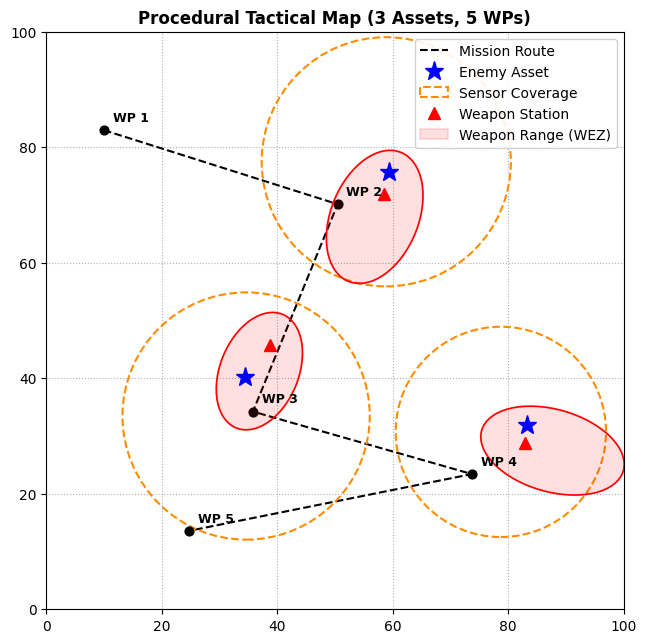

In [124]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.linalg as la

np.random.seed()

# 1DYNAMICALLY GENERATE ENEMY ASSETS (2 to 4)
num_assets = np.random.randint(2, 5)

assets = []
sensors = []
weapons = []

# Quadrants or specific offset spaces to keep them spread logically on a 100x100 grid
quadrants = [
    (55, 80, 50, 80),  # Top Right Area
    (15, 45, 15, 45),  # Bottom Left Area
    (60, 85, 15, 45),  # Bottom Right Area
    (15, 45, 50, 75)   # Top Left Area
]
# np.random.shuffle(quadrants) # Mix up positioning order

for idx in range(num_assets):
    xmin, xmax, ymin, ymax = quadrants[idx]
    pos_x = np.random.uniform(xmin, xmax)
    pos_y = np.random.uniform(ymin, ymax)
    asset_pos = (pos_x, pos_y)

    assets.append({"pos": asset_pos, "label": f"Asset {idx+1}"})

    sensors.append({
        "pos": (asset_pos[0] + np.random.uniform(-8, 5), asset_pos[1] + np.random.uniform(-8, 5)),
        "radius": np.random.uniform(18, 26)
    })

    weapons.append({
        "station": (asset_pos[0] + np.random.uniform(-6, 6), asset_pos[1] + np.random.uniform(-6, 6)),
        "a": np.random.uniform(10, 14),
        "b": np.random.uniform(6, 8.5),
        "offset": np.random.uniform(4, 6.5)
    })

num_waypoints = num_assets + np.random.randint(1, 4) # WAHOO LETYS GO GAMBLIG

wp_list = []
# Fixed safe start point
wp_list.append([10, np.random.uniform(75, 90)])

for w_idx in range(1, num_waypoints - 1):
    # make route close tosenseors
    target_sensor = sensors[min(w_idx - 1, len(sensors) - 1)]
    sx, sy = target_sensor["pos"]

    wp_x = np.clip(sx + np.random.uniform(-15, 15), 10, 90)
    wp_y = np.clip(sy + np.random.uniform(-15, 15), 10, 90)
    wp_list.append([wp_x, wp_y])

# finish wp
wp_list.append([np.random.uniform(10, 35), np.random.uniform(10, 30)])
waypoints = np.array(wp_list)

fig, ax1 = plt.subplots(figsize=(8, 7.5))

ax1.plot(waypoints[:, 0], waypoints[:, 1], 'k--', lw=1.5, label='Mission Route')
ax1.scatter(waypoints[:, 0], waypoints[:, 1], color='black', s=40, zorder=5)
for i, wp in enumerate(waypoints):
    ax1.text(wp[0] + 1.5, wp[1] + 1.5, f"WP {i+1}", fontsize=9, weight='bold', zorder=6)

for idx, asset in enumerate(assets):
    ax1.plot(asset["pos"][0], asset["pos"][1], 'b*', ms=14, zorder=7, label='Enemy Asset' if idx == 0 else "")

for idx, sensor in enumerate(sensors):
    circle = patches.Circle(sensor["pos"], sensor["radius"], edgecolor='darkorange', facecolor='none', linestyle='--', lw=1.5, zorder=4, label='Sensor Coverage' if idx == 0 else "")
    ax1.add_patch(circle)

for idx, weapon in enumerate(weapons):
    xw, yw = weapon["station"]

    distances = [np.linalg.norm(np.mean([waypoints[j], waypoints[j+1]], axis=0) - [xw, yw]) for j in range(len(waypoints)-1)]
    current_leg = np.argmin(distances)
    p1, p2 = waypoints[current_leg], waypoints[current_leg + 1]

    angle_rad = np.arctan2(p2[1] - p1[1], p2[0] - p1[0])

    # Shift ellipse center forward along velocity trajectory
    xc = xw + weapon["offset"] * np.cos(angle_rad)
    yc = yw + weapon["offset"] * np.sin(angle_rad)

    # Plot weapons infrastructure
    ax1.plot(xw, yw, 'r^', ms=9, zorder=5, label='Weapon Station' if idx == 0 else "")

    ellipse = patches.Ellipse(xy=(xc, yc), width=weapon["a"]*2, height=weapon["b"]*2, angle=np.degrees(angle_rad), edgecolor='red', facecolor='red', alpha=0.12, lw=1.5, zorder=5, label='Weapon Range (WEZ)' if idx == 0 else "")
    ax1.add_patch(ellipse)

    ellipse_outline = patches.Ellipse(xy=(xc, yc), width=weapon["a"]*2, height=weapon["b"]*2, angle=np.degrees(angle_rad), edgecolor='red', facecolor='none', lw=1.2, zorder=5)
    ax1.add_patch(ellipse_outline)

ax1.set_title(f"Procedural Tactical Map ({num_assets} Assets, {num_waypoints} WPs)", fontsize=12, weight='bold')
ax1.set_xlim(0, 100); ax1.set_ylim(0, 100); ax1.grid(True, ls=':'); ax1.set_aspect('equal')
ax1.legend(loc='upper right', framealpha=0.9)
plt.show()

State tracking graph, need to understand a bit. Mostly code from Claude

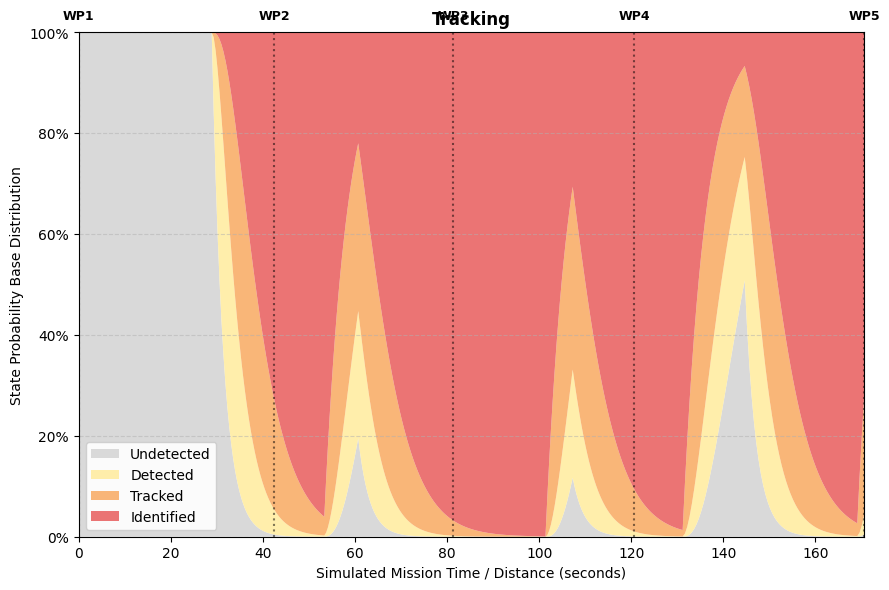

In [125]:
# 1. Sample the continuous flight path finely across legs
num_steps_per_leg = 100
path_points = []
for i in range(len(waypoints) - 1):
    leg = np.linspace(waypoints[i], waypoints[i+1], num_steps_per_leg, endpoint=False)
    path_points.extend(leg)
path_points.append(waypoints[-1])
path_points = np.array(path_points)

# Calculate elapsed step intervals assuming constant speed v = 1 unit/sec
segment_lengths = np.sqrt(np.sum(np.diff(path_points, axis=0)**2, axis=1))
time_steps = np.zeros(len(path_points))
time_steps[1:] = np.cumsum(segment_lengths)

# 2. Setup the Tracking States Matrix [Undetected, Detected, Tracked, Identified]
prob_history = np.zeros((len(path_points), 4))
prob_history[0] = [1.0, 0.0, 0.0, 0.0]  # Commences 100% undetected

# Transition parameter time values (from paper Table I)
tau_UD, tau_DT, tau_TT = 2.5, 3.3, 5.0  # Time to escalate right (inside radar)
tau_DU, tau_TD, tau_ID = 5.0, 5.0, 5.0  # Time to clear/regress left (outside radar)

# 3. Propagate state distributions dynamically along the trajectory coordinates
for t in range(1, len(path_points)):
    dt = time_steps[t] - time_steps[t-1]
    pos = path_points[t]

    # Evaluate sensor coverage geometry (Cartesian circle formula)
    sensors_covering = sum(1 for s in sensors if np.linalg.norm(pos - s["pos"]) <= s["radius"])

    # Construct infinitesimal generator matrix Λ
    Lambda = np.zeros((4, 4))
    if sensors_covering > 0:
        # Escalation transitions active inside radar coverage (scaled by overlap density)
        g_right = sensors_covering
        Lambda[0, 1] = g_right / tau_UD
        Lambda[1, 2] = g_right / tau_DT
        Lambda[2, 3] = g_right / tau_TT
    else:
        # Regression/forgetting transitions take over outside radar coverage
        Lambda[1, 0] = 1.0 / tau_DU
        Lambda[2, 1] = 1.0 / tau_TD
        Lambda[3, 2] = 1.0 / tau_ID

    # Apply row balance properties: Diagonals = -Sum(off-diagonals)
    for r in range(4):
        Lambda[r, r] = -np.sum(Lambda[r, :])

    # Calculate matrix exponential propagation: p(t) = p(t-dt) * e^(Λ * dt)
    prob_history[t] = prob_history[t-1] @ la.expm(Lambda * dt)

# 4. Generate Tracking State Probability Stacked Area Chart (Reproducing Figure 3)
fig, ax2 = plt.subplots(figsize=(9, 6))

ax2.stackplot(time_steps, prob_history[:, 0], prob_history[:, 1], prob_history[:, 2], prob_history[:, 3],
              labels=['Undetected', 'Detected', 'Tracked', 'Identified'],
              colors=['#d3d3d3', '#ffeb9c', '#f8a961', '#e85c5c'], alpha=0.85)

# Synchronize labels marking when waypoints occur chronologically on the timeline
wp_indices = [0] + [(j+1) * num_steps_per_leg for j in range(len(waypoints)-1)]
for idx, i in enumerate(wp_indices):
    t_val = time_steps[min(i, len(time_steps)-1)]
    ax2.axvline(x=t_val, color='black', linestyle=':', alpha=0.5)
    ax2.text(t_val, 1.02, f"WP{idx+1}", ha='center', va='bottom', fontsize=9, weight='bold')

ax2.set_title("Tracking", fontsize=12, weight='bold')
ax2.set_xlabel("Simulated Mission Time / Distance (seconds)")
ax2.set_ylabel("State Probability Base Distribution")
ax2.set_ylim(0, 1.0)
ax2.set_xlim(0, time_steps[-1])
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax2.legend(loc='lower left', framealpha=0.9)
ax2.grid(axis='y', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

Radials for Threat Value

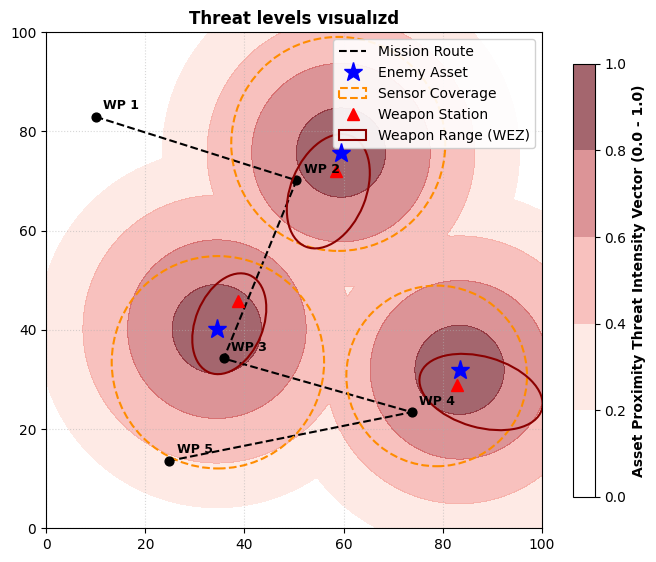

In [126]:
from matplotlib.colors import ListedColormap

grid_x, grid_y = np.meshgrid(np.linspace(0, 100, 200), np.linspace(0, 100, 200))
threat_grid = np.zeros_like(grid_x)

# Compute Radial Threat Values
influence_radius = 45.0
for asset in assets:
    ax_pos, ay_pos = asset["pos"]
    distance = np.sqrt((grid_x - ax_pos)**2 + (grid_y - ay_pos)**2)
    asset_threat = np.clip(1.0 - (distance / influence_radius), 0, 1)
    threat_grid = np.maximum(threat_grid, asset_threat)

fig, ax3 = plt.subplots(figsize=(8, 7.5))
levels = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

base_reds = plt.cm.Reds(np.linspace(0.3, 1.0, len(levels)-1))
opacities = [0, 0.15, 0.3, 0.45, 0.6]
for idx in range(len(opacities)):
    base_reds[idx, 3] = opacities[idx]
custom_cmap = ListedColormap(base_reds)

contour_plot = ax3.contourf(grid_x, grid_y, threat_grid,
                             levels=levels,
                             cmap=custom_cmap,
                             vmin=0, vmax=1)

ax3.plot(waypoints[:, 0], waypoints[:, 1], 'k--', lw=1.5, label='Mission Route')
ax3.scatter(waypoints[:, 0], waypoints[:, 1], color='black', s=40, zorder=5)
for i, wp in enumerate(waypoints):
    ax3.text(wp[0] + 1.5, wp[1] + 1.5, f"WP {i+1}", fontsize=9, weight='bold', zorder=6)

for asset in assets:
    ax3.plot(asset["pos"][0], asset["pos"][1], 'b*', ms=14, zorder=7, label='Enemy Asset' if asset == assets[0] else "")

for i, sensor in enumerate(sensors):
    circle = patches.Circle(sensor["pos"], sensor["radius"], edgecolor='darkorange', facecolor='none', linestyle='--', lw=1.5, zorder=4, label='Sensor Coverage' if i == 0 else "")
    ax3.add_patch(circle)

for i, weapon in enumerate(weapons):
    xw, yw = weapon["station"]
    distances = [np.linalg.norm(np.mean([waypoints[j], waypoints[j+1]], axis=0) - [xw, yw]) for j in range(len(waypoints)-1)]
    current_leg = np.argmin(distances)
    p1, p2 = waypoints[current_leg], waypoints[current_leg + 1]
    angle_rad = np.arctan2(p2[1] - p1[1], p2[0] - p1[0])

    xc = xw + weapon["offset"] * np.cos(angle_rad)
    yc = yw + weapon["offset"] * np.sin(angle_rad)

    ax3.plot(xw, yw, 'r^', ms=9, zorder=5, label='Weapon Station' if i == 0 else "")
    ellipse_outline = patches.Ellipse(xy=(xc, yc), width=weapon["a"]*2, height=weapon["b"]*2, angle=np.degrees(angle_rad), edgecolor='darkred', facecolor='none', lw=1.5, zorder=5, label='Weapon Range (WEZ)' if i == 0 else "")
    ax3.add_patch(ellipse_outline)

# Graph Layout Configuration
ax3.set_title("Threat levels vısualızd", fontsize=12, weight='bold')
ax3.set_xlim(0, 100); ax3.set_ylim(0, 100); ax3.grid(True, ls=':', alpha=0.5); ax3.set_aspect('equal')

# Colorbar
cbar = fig.colorbar(contour_plot, ax=ax3, shrink=0.75, pad=0.05, ticks=levels)
cbar.set_label('Asset Proximity Threat Intensity Vector (0.0 - 1.0)', weight='bold')

ax3.legend(loc='upper right', framealpha=0.9)
plt.show()

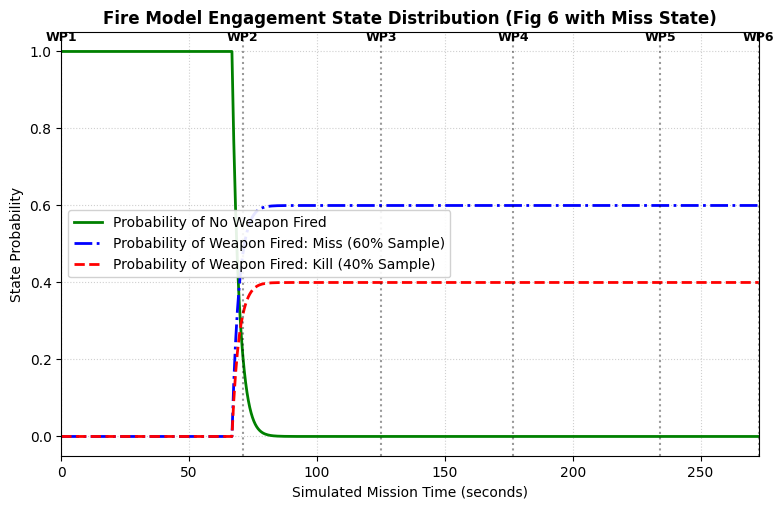

In [122]:
import scipy.linalg as la

p_identified = prob_history[:, 3] # State 3 from Cell 2
path_threat_values = np.zeros(len(path_points))
wez_geometric_factor = np.zeros(len(path_points))

influence_radius = 45.0
for t, pos in enumerate(path_points):
    max_t_val = 0
    for asset in assets:
        dist = np.linalg.norm(pos - asset["pos"])
        max_t_val = max(max_t_val, np.clip(1.0 - (dist / influence_radius), 0, 1))
    path_threat_values[t] = max_t_val

    inside_wez = 0
    for weapon in weapons:
        xw, yw = weapon["station"]
        distances = [np.linalg.norm(np.mean([waypoints[j], waypoints[j+1]], axis=0) - [xw, yw]) for j in range(len(waypoints)-1)]
        current_leg = np.argmin(distances)
        p1, p2 = waypoints[current_leg], waypoints[current_leg + 1]
        angle_rad = np.arctan2(p2[1] - p1[1], p2[0] - p1[0])

        xc = xw + weapon["offset"] * np.cos(angle_rad)
        yc = yw + weapon["offset"] * np.sin(angle_rad)

        dx, dy = pos[0] - xc, pos[1] - yc
        rot_x = dx * np.cos(angle_rad) + dy * np.sin(angle_rad)
        rot_y = -dx * np.sin(angle_rad) + dy * np.cos(angle_rad)

        if (rot_x**2 / weapon["a"]**2) + (rot_y**2 / weapon["b"]**2) <= 1.0:
            inside_wez = 1.0

    wez_geometric_factor[t] = inside_wez

# 2. Compute Firing Intensities μ(t)
base_firing_rate = 0.45
firing_intensity = base_firing_rate * p_identified * path_threat_values * wez_geometric_factor

# 3. Solve 3-State Fire Model: [0: No Fire, 1: Fired - Miss (60%), 2: Fired - Kill (40%)]
fire_probs = np.zeros((len(path_points), 3))
fire_probs[0] = [1.0, 0.0, 0.0] # Starts 100% with no weapon fired

p_kill_given_fire = 0.40
p_miss_given_fire = 0.60

for t in range(1, len(path_points)):
    dt = time_steps[t] - time_steps[t-1]
    mu = firing_intensity[t]

    # Expanded 3x3 transition matrix generator
    Lambda_F = np.array([
        [-mu,  mu * p_miss_given_fire,  mu * p_kill_given_fire],
        [ 0.0,                    0.0,                     0.0],
        [ 0.0,                    0.0,                     0.0]
    ])

    fire_probs[t] = fire_probs[t-1] @ la.expm(Lambda_F * dt)

# 4. Plot Figure 6
fig, ax4 = plt.subplots(figsize=(9, 5.5))
ax4.plot(time_steps, fire_probs[:, 0], 'g-', lw=2, label='Probability of No Weapon Fired')
ax4.plot(time_steps, fire_probs[:, 1], 'b-.', lw=2, label='Probability of Weapon Fired: Miss (60% Sample)')
ax4.plot(time_steps, fire_probs[:, 2], 'r--', lw=2, label='Probability of Weapon Fired: Kill (40% Sample)')

# Synchronize Waypoint vertical lines
for idx, i in enumerate(wp_indices):
    t_val = time_steps[min(i, len(time_steps)-1)]
    ax4.axvline(x=t_val, color='black', linestyle=':', alpha=0.4)
    ax4.text(t_val, 1.02, f"WP{idx+1}", ha='center', va='bottom', fontsize=9, weight='bold')

ax4.set_title("Fire Model Engagement State Distribution (Fig 6 with Miss State)", fontsize=12, weight='bold')
ax4.set_xlabel("Simulated Mission Time (seconds)")
ax4.set_ylabel("State Probability")
ax4.set_ylim(-0.05, 1.05)
ax4.set_xlim(0, time_steps[-1])
ax4.grid(True, ls=':', alpha=0.6)
ax4.legend(loc='center left', framealpha=0.9)
plt.show()

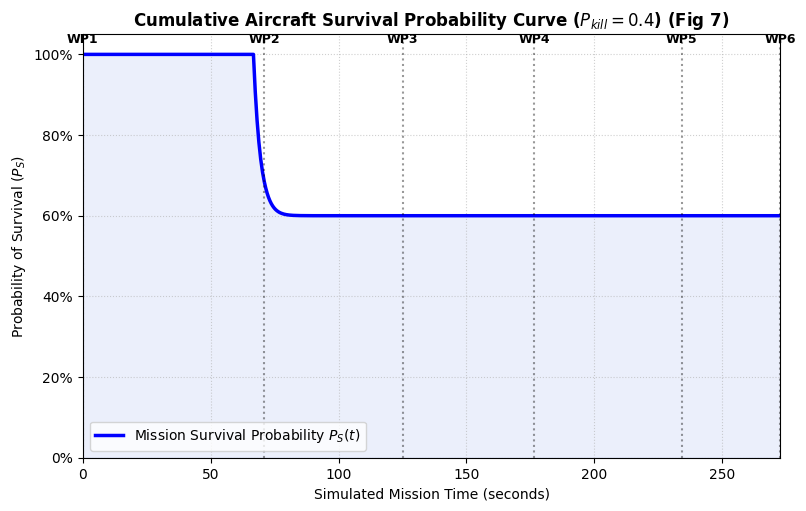

In [123]:
# =========================================================
# CELL 5: CUMULATIVE SURVIVAL PROBABILITY (FIGURE 7 REPLICA)
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Survival calculation directly tied to the new 3-state Fire Model math
# Aircraft survives if there is no fire OR if the fire misses (1 - P_kill)
survival_prob = fire_probs[:, 0] + fire_probs[:, 1]

# 2. Plot Figure 7
fig, ax5 = plt.subplots(figsize=(9, 5.5))
ax5.plot(time_steps, survival_prob, 'b-', lw=2.5, label='Mission Survival Probability $P_S(t)$')

# Fill danger area context under the survival curve
ax5.fill_between(time_steps, survival_prob, color='royalblue', alpha=0.1)

# Synchronize Waypoint vertical lines
for idx, i in enumerate(wp_indices):
    t_val = time_steps[min(i, len(time_steps)-1)]
    ax5.axvline(x=t_val, color='black', linestyle=':', alpha=0.4)
    ax5.text(t_val, 1.02, f"WP{idx+1}", ha='center', va='bottom', fontsize=9, weight='bold')

ax5.set_title("Cumulative Aircraft Survival Probability Curve ($P_{kill} = 0.4$) (Fig 7)", fontsize=12, weight='bold')
ax5.set_xlabel("Simulated Mission Time (seconds)")
ax5.set_ylabel("Probability of Survival ($P_S$)")
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax5.set_ylim(0.0, 1.05)
ax5.set_xlim(0, time_steps[-1])
ax5.grid(True, ls=':', alpha=0.6)
ax5.legend(loc='lower left')
plt.show()